In [2]:
import numpy as np
from PIL import Image
import tf_keras as keras
from tf_keras import layers
from keras.applications import efficientnet

In [3]:
pistachio_sample = np.array(Image.open('Pistachio_Image_Dataset/Kirmizi_Pistachio/kirmizi (1).jpg'))
pistachio_sample.shape

(600, 600, 3)

In [4]:
efficientnetb7 = keras.applications.EfficientNetB7()
predict = efficientnetb7.predict(pistachio_sample[np.newaxis,:])
efficientnet.decode_predictions( predict )

I0000 00:00:1776392934.415458    4628 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1776392934.557644    4628 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1776392934.557676    4628 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1776392934.559313    4628 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1776392934.559341    4628 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

1/1 [==============================] - 3s 3s/step


[[('n01950731', 'sea_slug', 0.23459385),
  ('n01924916', 'flatworm', 0.20696923),
  ('n01943899', 'conch', 0.08625129),
  ('n01945685', 'slug', 0.08494818),
  ('n01955084', 'chiton', 0.028249668)]]

#### 전이 학습

In [15]:
keras_efficb0_base = keras.applications.EfficientNetB0(include_top=False) #분류기를 제외한 베이스모델
feature_map = keras_efficb0_base(pistachio_sample[np.newaxis,:])
feature_map.shape

TensorShape([1, 18, 18, 1280])

In [14]:
train_ds, val_ds = keras.utils.image_dataset_from_directory('Pistachio_Image_Dataset',image_size=(224,224), batch_size=16, 
                                                            validation_split=0.2, subset='both', seed=42)

Found 2150 files belonging to 2 classes.
Using 1720 files for training.
Using 430 files for validation.


In [16]:
keras_efficb0_base.trainable 

In [17]:
inputs = keras.Input(shape=(224,224,3))
x = keras_efficb0_base(inputs)
x = layers.GlobalAveragePooling2D() (x)
x = layers.Dense(128, activation='relu') (x)
outputs = layers.Dense(1, activation = 'sigmoid') (x)
model = keras.Model(inputs, outputs)

In [18]:
rmsprop = keras.optimizers.RMSprop( learning_rate=5e-5 )
model.compile ( optimizer=rmsprop, loss='binary_crossentropy', metrics=['accuracy'] )
hist = model.fit( train_ds, epochs=20, validation_data=val_ds )

Epoch 1/20


W0000 00:00:1776393914.310428    4893 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776393914.328598    4893 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776393914.348169    4893 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776393914.366005    4893 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776393914.383914    4893 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776393914.400625    4893 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776393914.416690    4893 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776393914.433423    4893 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776393914.455297    4893 gp

  1/108 [..............................] - ETA: 5:53 - loss: 0.8542 - accuracy: 0.3125

I0000 00:00:1776393915.139196    4893 service.cc:146] XLA service 0x714e548199c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776393915.139227    4893 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Ti, Compute Capability 8.9
2026-04-17 11:45:15.147993: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776393915.217010    4893 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


108/108 [==============================] - ETA: 0s - loss: 0.5300 - accuracy: 0.7709

W0000 00:00:1776393917.257624    4892 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776393917.258343    4892 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776393917.259084    4892 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776393917.259754    4892 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776393917.260393    4892 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776393917.260981    4892 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776393917.261560    4892 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776393917.262152    4892 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776393917.262715    4892 gp

108/108 [==============================] - 6s 29ms/step - loss: 0.5300 - accuracy: 0.7709 - val_loss: 0.3918 - val_accuracy: 0.8837
Epoch 2/20
  7/108 [>.............................] - ETA: 1s - loss: 0.3679 - accuracy: 0.9018

W0000 00:00:1776393918.400682    4895 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776393918.401480    4895 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776393918.402196    4895 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776393918.402842    4895 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776393918.403475    4895 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776393918.404134    4895 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776393918.404771    4895 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776393918.405437    4895 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776393918.406094    4895 gp

108/108 [==============================] - 2s 23ms/step - loss: 0.3308 - accuracy: 0.9047 - val_loss: 0.2708 - val_accuracy: 0.9140
Epoch 3/20
108/108 [==============================] - 2s 23ms/step - loss: 0.2473 - accuracy: 0.9285 - val_loss: 0.2112 - val_accuracy: 0.9302
Epoch 4/20
108/108 [==============================] - 2s 23ms/step - loss: 0.1942 - accuracy: 0.9477 - val_loss: 0.1748 - val_accuracy: 0.9419
Epoch 5/20
108/108 [==============================] - 2s 23ms/step - loss: 0.1625 - accuracy: 0.9547 - val_loss: 0.1495 - val_accuracy: 0.9488
Epoch 6/20
108/108 [==============================] - 2s 23ms/step - loss: 0.1407 - accuracy: 0.9645 - val_loss: 0.1307 - val_accuracy: 0.9605
Epoch 7/20
108/108 [==============================] - 6s 56ms/step - loss: 0.1273 - accuracy: 0.9622 - val_loss: 0.1182 - val_accuracy: 0.9628
Epoch 8/20
108/108 [==============================] - 2s 23ms/step - loss: 0.1144 - accuracy: 0.9709 - val_loss: 0.1106 - val_accuracy: 0.9674
Epoch 9/20

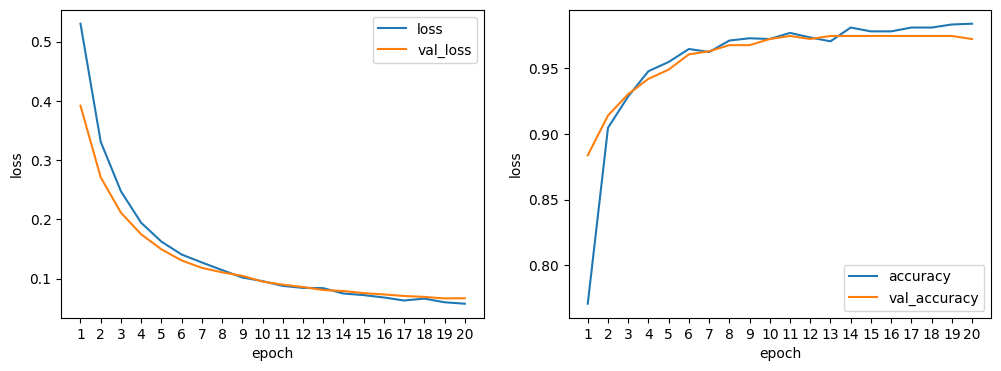

In [24]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(12,4))
axs[0].plot(range(1, 21), hist.history['loss'], label='loss')
axs[0].plot(range(1, 21), hist.history['val_loss'], label='val_loss')
axs[0].set_xticks(range(1,21))
axs[0].set_xlabel('epoch')
axs[0].set_ylabel('loss')
axs[0].legend()

axs[1].plot(range(1, 21), hist.history['accuracy'], label='accuracy')
axs[1].plot(range(1, 21), hist.history['val_accuracy'], label='val_accuracy')
axs[1].set_xticks(range(1,21))
axs[1].set_xlabel('epoch')
axs[1].set_ylabel('loss')
axs[1].legend()
plt.show()

In [22]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 94.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 90.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 57.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]
